# RL in Real-World Systems

## From Theory to Industry Applications

This notebook demonstrates RL concepts through **4 real-world system analogues**:

| System | RL Analogue | Industry |
|--------|------------|----------|
| **Dynamic Pricing** | Multi-Armed Bandit | E-commerce / Airlines |
| **Hospital Triage Routing** | Q-Learning | Healthcare / RCM |
| **Inventory Management** | RL Agent | Supply Chain / Retail |

---

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

np.random.seed(42)
print('Libraries loaded')

Libraries loaded


---
## System 1: Dynamic Pricing Engine
### Industry: E-commerce, Airlines, Hotels (Emirates, Carrefour)

**RL Framing:**
- **Agent**: Pricing algorithm
- **State**: Time of day, stock level, demand history
- **Action**: Which price tier to show (3 options)
- **Reward**: Revenue per transaction

**Algorithm Used: Multi-Armed Bandit (ε-greedy)**  
Each price = one "arm" of a slot machine. The agent learns which arm generates the most revenue.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# ============================================================
# CELL 2: Dynamic Pricing — Multi-Armed Bandit
# ============================================================

class DynamicPricingBandit:
    """3 price tiers for a product. True expected revenue is unknown to agent."""

    def __init__(self):
        # Price tiers : Low=49, Mid=79, High=119
        self.prices = [49, 79, 119]
        # True conversion probabilities (unknown to agent)
        self.true_conversion = [0.70, 0.55, 0.28]
        self.n_arms = len(self.prices)

    def pull(self, arm):
        """Simulate one customer interaction."""
        if np.random.random() < self.true_conversion[arm]:
            return self.prices[arm]  # sale made
        else:
            return 0  # no sale

    @property
    def true_expected_revenue(self):
        return [p * c for p, c in zip(self.prices, self.true_conversion)]

    @property
    def optimal_arm(self):
        return np.argmax(self.true_expected_revenue)

In [26]:
class EpsilonGreedyBandit:
    """ε-greedy bandit agent."""

    def __init__(self, n_arms, epsilon):
        self.n_arms  = n_arms
        self.epsilon = epsilon
        self.counts  = np.zeros(n_arms)   # how many times each arm tried
        self.values  = np.zeros(n_arms)   # estimated revenue per arm

    def select_arm(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms), 'explore'
        return np.argmax(self.values), 'exploit'

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] = ((n-1)/n) * self.values[arm] + (1/n) * reward

In [27]:
# Run simulation: 3 epsilon strategies for 1000 customers
bandit  = DynamicPricingBandit()
n_steps = 1000

In [28]:
print(f'Dynamic Pricing — Emirates e-Store (Fictional)')
print(f'Product: Business Lounge Day Pass')
print(f'Price Tiers: {bandit.prices}')
print(f'True Conversion Rates: {bandit.true_conversion}')
print(f'True Expected Revenue: {[f"{r:.1f}".format() for r in bandit.true_expected_revenue]}')
print(f'Optimal Price Tier: {bandit.prices[bandit.optimal_arm]}')
print()

Dynamic Pricing — Emirates e-Store (Fictional)
Product: Business Lounge Day Pass
Price Tiers: [49, 79, 119]
True Conversion Rates: [0.7, 0.55, 0.28]
True Expected Revenue: ['34.3', '43.5', '33.3']
Optimal Price Tier: 79



In [29]:
results = {}
for eps in [0.0, 0.1, 0.3]:
    agent     = EpsilonGreedyBandit(bandit.n_arms, epsilon=eps)
    revenues  = []
    cum_rev   = []
    total     = 0

    for t in range(n_steps):
        arm, _ = agent.select_arm()
        reward = bandit.pull(arm)
        agent.update(arm, reward)
        total += reward
        revenues.append(reward)
        cum_rev.append(total)

    results[eps] = {'revenues': revenues, 'cum_rev': cum_rev,
                    'final_values': agent.values.copy(),
                    'final_counts': agent.counts.copy()}
    print(f'ε={eps}: Total Revenue = {total:,} AED | '
          f'Learned Values = {[f"{v:.1f}" for v in agent.values]}')

ε=0.0: Total Revenue = 34,104 AED | Learned Values = ['34.1', '0.0', '0.0']
ε=0.1: Total Revenue = 42,228 AED | Learned Values = ['33.8', '43.8', '29.7']
ε=0.3: Total Revenue = 39,030 AED | Learned Values = ['34.2', '42.0', '36.5']


In [30]:
# Optimal (oracle) revenue
optimal_arm = bandit.optimal_arm
oracle_rewards = [bandit.pull(optimal_arm) for _ in range(n_steps)]
oracle_cum = np.cumsum(oracle_rewards)

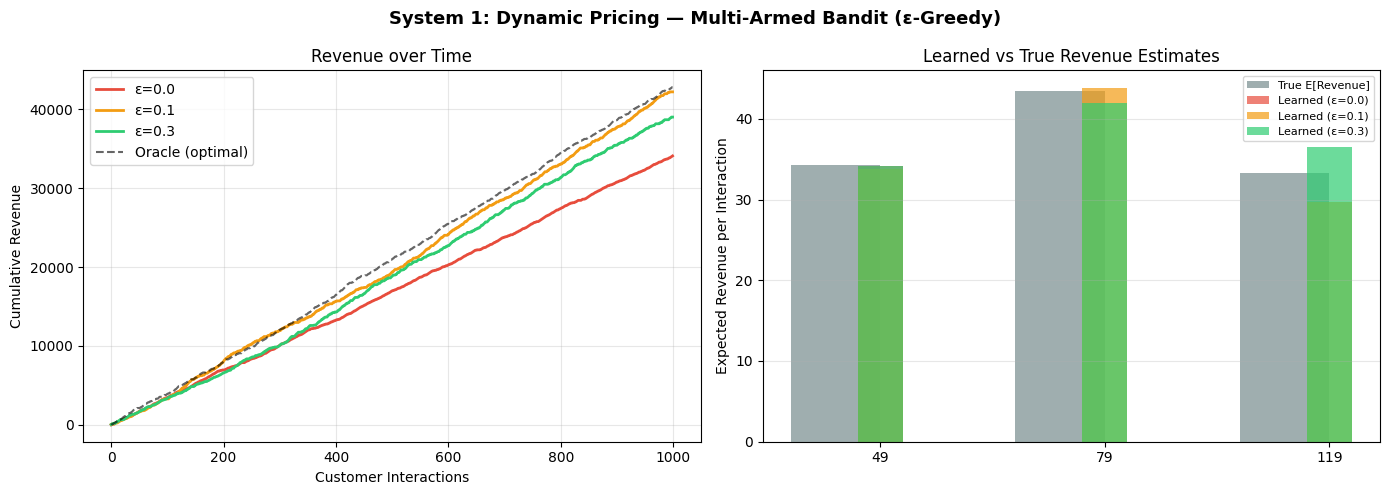

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('System 1: Dynamic Pricing — Multi-Armed Bandit (ε-Greedy)',
             fontsize=13, fontweight='bold')

colors = ['#e74c3c', '#f39c12', '#2ecc71']
for (eps, data), color in zip(results.items(), colors):
    axes[0].plot(data['cum_rev'], color=color, lw=2, label=f'ε={eps}')
axes[0].plot(oracle_cum, 'k--', lw=1.5, alpha=0.6, label='Oracle (optimal)')
axes[0].set_xlabel('Customer Interactions')
axes[0].set_ylabel('Cumulative Revenue')
axes[0].set_title('Revenue over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learned vs True Q-values
x = np.arange(bandit.n_arms)
axes[1].bar(x - 0.2, bandit.true_expected_revenue, 0.4,
            label='True E[Revenue]', color='#95a5a6', alpha=0.9)
for (eps, data), color in zip(results.items(), colors):
    axes[1].bar(x, data['final_values'], 0.2,
                label=f'Learned (ε={eps})', color=color, alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{p}' for p in bandit.prices])
axes[1].set_ylabel('Expected Revenue per Interaction')
axes[1].set_title('Learned vs True Revenue Estimates')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## System 2: Hospital Patient Triage Routing
### Industry: Healthcare Operations, RCM (Cleveland Clinic Abu Dhabi, Mediclinic)

**RL Framing:**
- **State**: Patient acuity score (1=critical → 5=minor), queue lengths
- **Action**: Route to ICU, ED Fast Track, or General Ward
- **Reward**: +10 appropriate routing, -5 under-triaged (critical to general), -2 over-triaged
- **Algorithm**: Q-Learning

In [32]:
# ============================================================
# CELL 4: Hospital Triage Routing Agent
# ============================================================

# States: acuity levels 1–5 (5 states)
# Actions: 0=ICU, 1=ED_FastTrack, 2=General_Ward

ACUITY = {1: 'Critical', 2: 'High', 3: 'Moderate', 4: 'Low', 5: 'Minor'}
ROUTES = {0: 'ICU', 1: 'ED Fast Track', 2: 'General Ward'}

# Clinical guidelines: correct routing per acuity
# 1=ICU, 2=ICU, 3=FastTrack, 4=FastTrack, 5=General
CORRECT_ROUTE = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2}  # state → action

In [33]:
def triage_reward(acuity_state, action):
    """Reward based on clinical appropriateness."""
    correct = CORRECT_ROUTE[acuity_state]

    if action == correct:
        return +10  # correct routing
    elif action > correct:  # under-triage (too lenient)
        severity = (action - correct)
        return -5 * severity  # dangerous
    else:  # over-triage (too aggressive)
        return -2  # wastes resources but less dangerous

In [34]:
class TriageAgent:
    """Q-learning triage routing agent."""

    def __init__(self, n_states=5, n_actions=3, alpha=0.15, gamma=0.9, epsilon=0.5):
        self.Q       = np.zeros((n_states, n_actions))
        self.alpha   = alpha
        self.gamma   = gamma
        self.epsilon = epsilon
        self.n_actions = n_actions

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])

    def update(self, state, action, reward):
        # Simplified Q-update (episodic, no next-state here)
        self.Q[state, action] += self.alpha * (reward - self.Q[state, action])

In [35]:
# Train over 1000 patient interactions
agent = TriageAgent(epsilon=0.5)
n_patients = 1000
accuracy_window = []
correct_history = []

for i in range(n_patients):
    # Random patient acuity
    acuity_state = np.random.randint(0, 5)

    # Decay epsilon gradually
    agent.epsilon = max(0.05, 0.5 * (1 - i / n_patients))

    action = agent.select_action(acuity_state)
    reward = triage_reward(acuity_state, action)
    agent.update(acuity_state, action, reward)

    correct = 1 if action == CORRECT_ROUTE[acuity_state] else 0
    correct_history.append(correct)

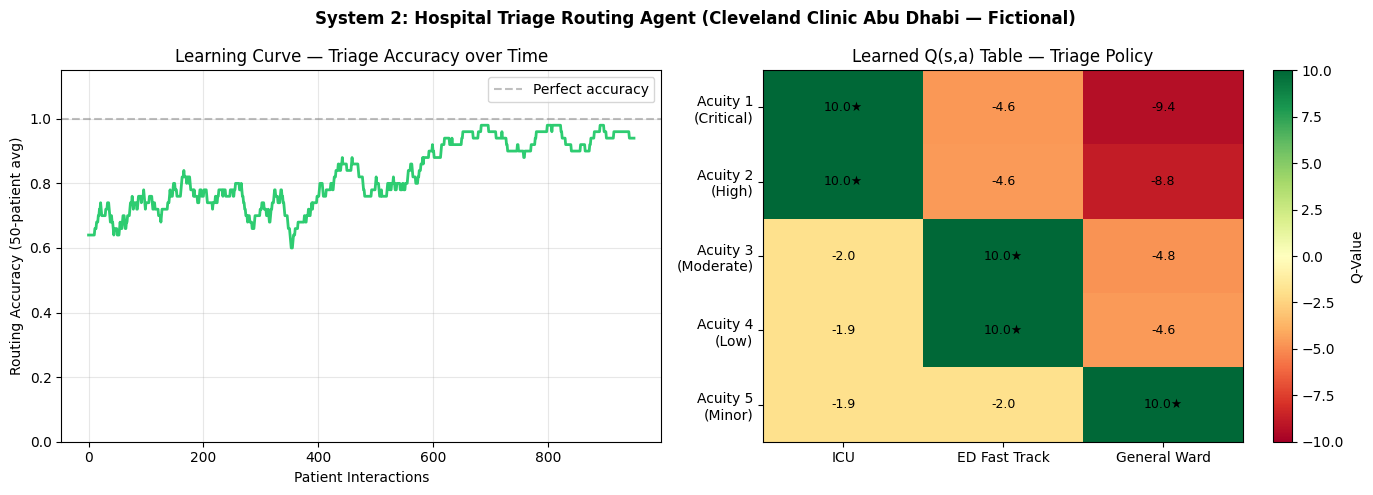


★ = Clinically correct route per acuity level
Final accuracy (last 100 patients): 95%


In [36]:
window = 50
accuracy_curve = np.convolve(correct_history, np.ones(window)/window, mode='valid')

# Display results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('System 2: Hospital Triage Routing Agent (Cleveland Clinic Abu Dhabi — Fictional)',
             fontsize=12, fontweight='bold')

# Accuracy curve
axes[0].plot(accuracy_curve, color='#2ecc71', lw=2)
axes[0].axhline(1.0, color='gray', ls='--', alpha=0.5, label='Perfect accuracy')
axes[0].set_xlabel('Patient Interactions')
axes[0].set_ylabel('Routing Accuracy (50-patient avg)')
axes[0].set_title('Learning Curve — Triage Accuracy over Time')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-table visualised
im = axes[1].imshow(agent.Q, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['ICU', 'ED Fast Track', 'General Ward'])
axes[1].set_yticks(range(5))
axes[1].set_yticklabels([f'Acuity {i+1}\n({ACUITY[i+1]})' for i in range(5)])
axes[1].set_title('Learned Q(s,a) Table — Triage Policy')
plt.colorbar(im, ax=axes[1], label='Q-Value')

for r in range(5):
    for c in range(3):
        marker = '★' if c == CORRECT_ROUTE[r] else ''
        axes[1].text(c, r, f'{agent.Q[r,c]:.1f}{marker}',
                     ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

print('\n★ = Clinically correct route per acuity level')
print(f'Final accuracy (last 100 patients): {np.mean(correct_history[-100:]):.0%}')

---
## System 3: Inventory Management
### Industry: Retail / Supply Chain (UAE: Carrefour, LuLu Hypermarket, Amazon MENA)

**RL Framing:**
- **State**: Current stock level (0–20 units)
- **Action**: Order quantity (0, 5, 10, or 15 units)
- **Reward**: Revenue from sales − holding costs − stockout penalty
- **Algorithm**: Q-Learning

In [37]:
# ============================================================
# CELL 6: Inventory Management Agent
# ============================================================

class InventoryEnv:
    """Simple inventory management environment."""

    MAX_STOCK   = 20
    ORDER_OPTS  = [0, 5, 10, 15]
    SALE_PRICE  = 50   # AED per unit
    HOLD_COST   = 2    # AED per unit per day
    STOCKOUT_PENALTY = 30  # AED per unmet demand

    def __init__(self):
        self.stock = 10

    def reset(self):
        self.stock = 10
        return self.stock

    def step(self, action_idx):
        order = self.ORDER_OPTS[action_idx]

        # Receive order (assume instant delivery for simplicity)
        self.stock = min(self.MAX_STOCK, self.stock + order)

        # Random daily demand: Poisson λ=8
        demand = min(15, max(0, int(np.random.poisson(8))))

        # Fulfil demand
        sold     = min(self.stock, demand)
        unmet    = max(0, demand - self.stock)
        self.stock -= sold

        # Reward calculation
        revenue  = sold * self.SALE_PRICE
        holding  = self.stock * self.HOLD_COST
        penalty  = unmet * self.STOCKOUT_PENALTY
        reward   = revenue - holding - penalty

        return self.stock, reward, {'sold': sold, 'unmet': unmet, 'demand': demand}

In [38]:
class InventoryQLearner:
    def __init__(self, n_states=21, n_actions=4, alpha=0.1, gamma=0.95, epsilon=0.4):
        self.Q = np.zeros((n_states, n_actions))
        self.alpha = alpha; self.gamma = gamma; self.epsilon = epsilon
        self.n_actions = n_actions

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])

    def update(self, s, a, r, s_next):
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

In [39]:
# Train and evaluate
env   = InventoryEnv()
agent = InventoryQLearner()
n_days = 2000
daily_rewards, stock_levels = [], []

for day in range(n_days):
    state = env.stock
    agent.epsilon = max(0.05, 0.4 * (1 - day / n_days))
    action = agent.select_action(state)
    next_state, reward, info = env.step(action)
    agent.update(state, action, reward, next_state)
    daily_rewards.append(reward)
    stock_levels.append(next_state)

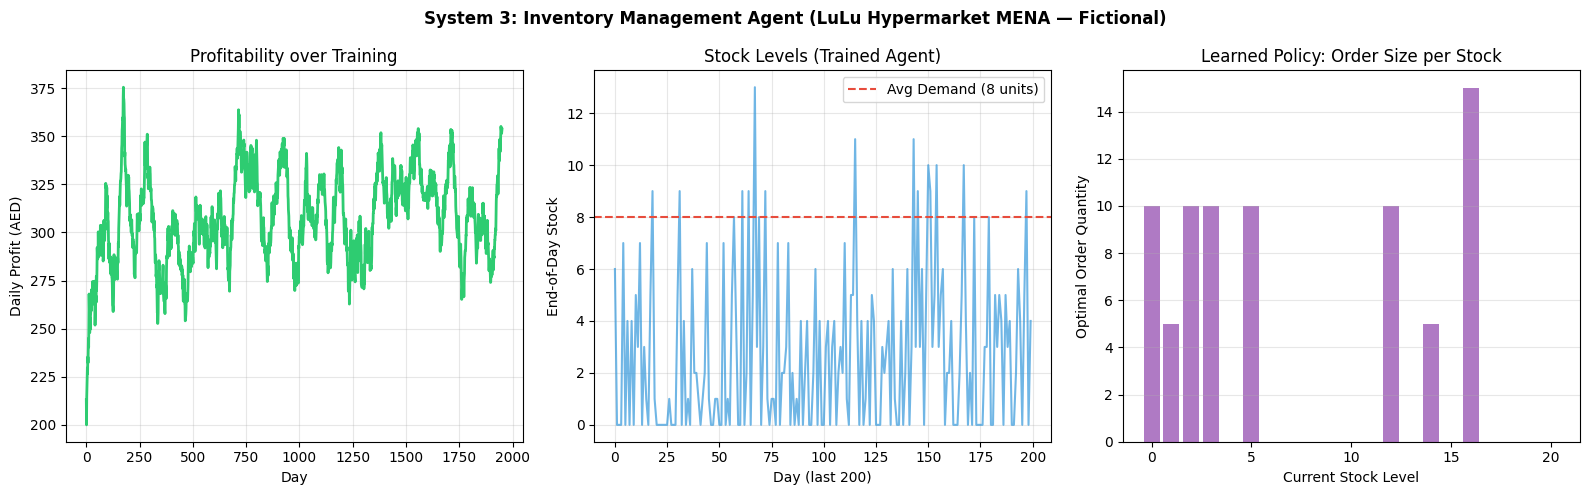


Agent learned: order MORE when stock is LOW, less when stock is HIGH
   Avg daily profit (last 200 days): AED 313


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('System 3: Inventory Management Agent (LuLu Hypermarket MENA — Fictional)',
             fontsize=12, fontweight='bold')

# Revenue over time
w = 50
axes[0].plot(np.convolve(daily_rewards, np.ones(w)/w, 'valid'),
             color='#2ecc71', lw=2)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Daily Profit (AED)')
axes[0].set_title('Profitability over Training')
axes[0].grid(True, alpha=0.3)

# Stock levels (last 200 days)
axes[1].plot(stock_levels[-200:], color='#3498db', alpha=0.7)
axes[1].axhline(8, color='#e74c3c', ls='--', label='Avg Demand (8 units)')
axes[1].set_xlabel('Day (last 200)')
axes[1].set_ylabel('End-of-Day Stock')
axes[1].set_title('Stock Levels (Trained Agent)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learned policy: optimal order per stock level
optimal_orders = [InventoryEnv.ORDER_OPTS[np.argmax(agent.Q[s])] for s in range(21)]
axes[2].bar(range(21), optimal_orders, color='#9b59b6', alpha=0.8)
axes[2].set_xlabel('Current Stock Level')
axes[2].set_ylabel('Optimal Order Quantity')
axes[2].set_title('Learned Policy: Order Size per Stock')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'\nAgent learned: order MORE when stock is LOW, less when stock is HIGH')
print(f'   Avg daily profit (last 200 days): AED {np.mean(daily_rewards[-200:]):.0f}')

---
## Summary: RL Framework Across Real Systems

| Component | Dynamic Pricing | Hospital Triage | Inventory Mgmt |
|-----------|----------------|----------------|----------------|
| **Environment** | Customer demand | Patient flow | Market demand |
| **State** | Context/stock | Acuity score | Stock level |
| **Action** | Price tier | Route (ICU/ED/General) | Order quantity |
| **Reward** | Revenue | Accuracy / safety | Profit |
| **Algorithm** | Multi-Armed Bandit | Q-Learning | Q-Learning |
| **Challenge** | Explore vs exploit | Sparse critical cases | Demand stochasticity |